## **CLASIFICACION DE FORMACIONES DE FUTBOL**

In [1]:
from PIL import Image
import numpy as np
import pandas as pd
import os
import torch
df = pd.read_csv("dataset_formaciones_15_clases.csv")

In [2]:
df.head(10)

,0,1,2,3,4,5,6,7,8,9,...,29991,29992,29993,29994,29995,29996,29997,29998,29999,clase
0,0.101961,0.537255,0.129412,0.062745,0.533333,0.133333,0.066667,0.533333,0.129412,0.066667,...,0.090196,0.552941,0.129412,0.101961,0.552941,0.133333,0.129412,0.560784,0.137255,0
1,0.047059,0.290196,0.070588,0.031373,0.290196,0.074510,0.031373,0.294118,0.058824,0.035294,...,0.043137,0.298039,0.058824,0.047059,0.301961,0.062745,0.058824,0.309804,0.062745,0
2,0.086275,0.411765,0.094118,0.050980,0.407843,0.101961,0.054902,0.407843,0.090196,0.054902,...,0.070588,0.431373,0.101961,0.074510,0.427451,0.101961,0.098039,0.435294,0.101961,0
3,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0
4,0.003922,0.000000,0.003922,0.019608,0.000000,0.019608,0.039216,0.305882,0.101961,0.003922,...,0.054902,0.317647,0.105882,0.011765,0.000000,0.011765,0.000000,0.000000,0.003922,0
5,0.498039,1.000000,0.435294,0.478431,1.000000,0.431373,0.474510,0.996078,0.419608,0.490196,...,0.517647,0.980392,0.486274,0.490196,0.996078,0.439216,0.498039,1.000000,0.443137,0
6,0.270588,0.580392,0.235294,0.262745,0.568627,0.243137,0.254902,0.568627,0.231373,0.262745,...,0.250980,0.572549,0.231373,0.254902,0.584314,0.231373,0.266667,0.580392,0.247059,0
7,0.392157,0.823529,0.337255,0.368627,0.819608,0.333333,0.360784,0.819608,0.325490,0.364706,...,0.384314,0.807843,0.349020,0.368627,0.831373,0.329412,0.384314,0.827451,0.345098,0
8,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0
9,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.101961,0.239216,0.090196,0.470588,...,0.109804,0.239216,0.105882,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0


### Sepacion de la Caracteristcias (X) y las Label (y)

In [3]:
X = df.drop("clase", axis=1)

y = df["clase"]

In [4]:
m,n = X.shape
print("Cantidad de imágenes:", m)
print("Número de características:", n)

Cantidad de imágenes: 1500
Número de características: 30000


### Separar 80% entrenamiento y 20% prueba 

In [5]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)

In [6]:
X_t = torch.from_numpy(X_train.to_numpy()).float()
Y_t = torch.from_numpy(y_train.to_numpy()).long()
X_te = torch.from_numpy(X_test.to_numpy()).float()
Y_te = torch.from_numpy(y_test.to_numpy()).long()

C:\Users\ASUS\AppData\Local\Temp\ipykernel_4392\2458802188.py:2: UserWarning: The given NumPy array is not writable, and PyTorch does not support non-writable tensors. This means writing to this tensor will result in undefined behavior. You may want to copy the array to protect its data or make it writable before converting it to a tensor. This type of warning will be suppressed for the rest of this program. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\torch\csrc\utils\tensor_numpy.cpp:219.)
  Y_t = torch.from_numpy(y_train.to_numpy()).long()


### Definimos el Modelo o nuestra Red Neuronal 

f(x)=x           si x > 0
f(x)=0.01·x      si x ≤ 0

In [7]:
model = torch.nn.Sequential(
    torch.nn.Linear(30000, 128),
    torch.nn.ReLU(),
    torch.nn.Dropout(0.3),
    torch.nn.Linear(128, 15)
)

### Definicion de funcion Softmax 

In [8]:
def softmax(x):
    return torch.exp(x) / torch.exp(x).sum(axis=-1,keepdims=True)

### Definicion de funcion Evaluacion

In [9]:
from sklearn.metrics import accuracy_score

def evaluate(x):
    model.eval()
    y_pred = model(x)
    y_probas = softmax(y_pred)
    return torch.argmax(y_probas, axis=1)

usamos SGD Descenso de gradiente estocástico 

In [10]:
import torch
import torch.nn as nn
from sklearn.metrics import accuracy_score
import numpy as np
criterion = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(model.parameters(), lr=0.01)

epochs = 3000
log_each = 200
l = []
model.train()
for e in range(1, epochs+1):

    y_pred = model(X_t)

    loss = criterion(y_pred, Y_t)
    l.append(loss.item())

    optimizer.zero_grad()

    loss.backward()
     
    optimizer.step()

    if not e % log_each:
        print(f"Epoch {e}/{epochs} Loss {np.mean(l):.5f}")

Epoch 200/3000 Loss 2.06567
Epoch 400/3000 Loss 1.64830
Epoch 600/3000 Loss 1.33875
Epoch 800/3000 Loss 1.11773
Epoch 1000/3000 Loss 0.95583
Epoch 1200/3000 Loss 0.83391
Epoch 1400/3000 Loss 0.73913
Epoch 1600/3000 Loss 0.66357
Epoch 1800/3000 Loss 0.60197
Epoch 2000/3000 Loss 0.55089
Epoch 2200/3000 Loss 0.50784
Epoch 2400/3000 Loss 0.47110
Epoch 2600/3000 Loss 0.43936
Epoch 2800/3000 Loss 0.41167
Epoch 3000/3000 Loss 0.38732


In [11]:
from sklearn.metrics import confusion_matrix

y_pred = evaluate(X_t).cpu().numpy()
y_real = Y_t.cpu().numpy()

cm = confusion_matrix(y_real, y_pred)

print(cm)

[[80  0  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0 80  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0 80  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0 80  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0 80  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0 80  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0 80  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  0 80  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  0  0 80  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  0  0  0 80  0  0  0  0  0]
 [ 0  0  0  0  0  0  0  0  0  0 80  0  0  0  0]
 [ 0  0  0  0  0  0  0  0  0  0  0 80  0  0  0]
 [ 0  0  0  0  0  0  0  0  0  0  0  0 80  0  0]
 [ 0  0  0  0  0  0  0  0  0  0  0  0  0 80  0]
 [ 0  0  0  0  0  0  0  0  0  0  0  0  0  0 80]]


### La Matriz de Confusion 

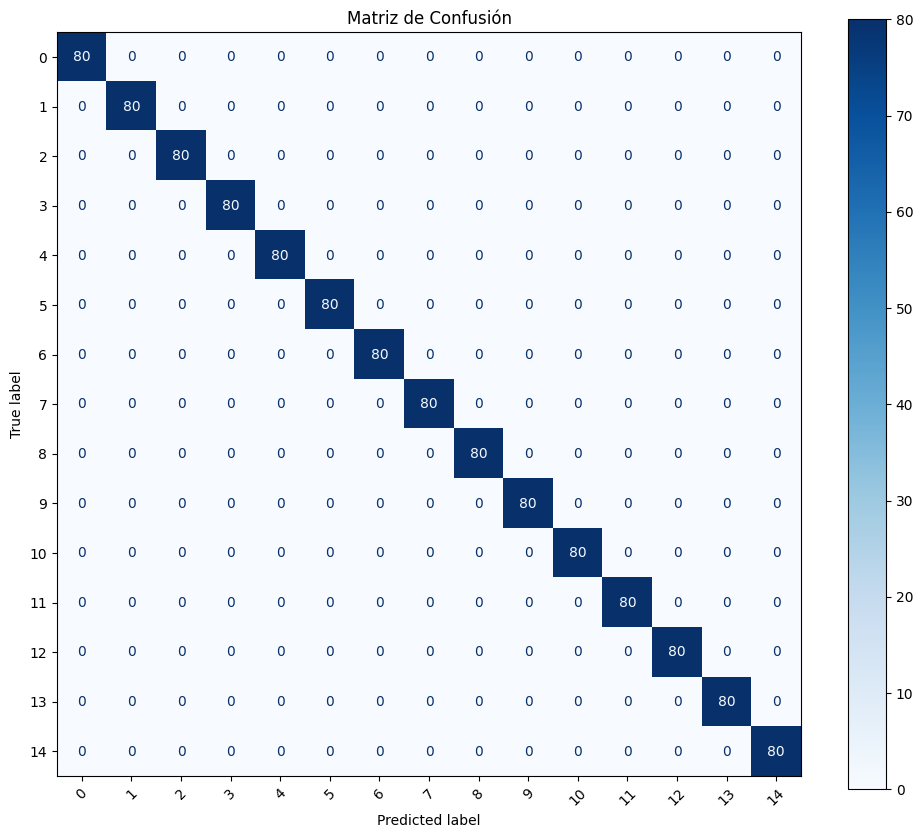

In [12]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

fig, ax = plt.subplots(figsize=(12,10))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=range(15)
)

disp.plot(
    ax=ax,
    cmap="Blues",    xticks_rotation=45
)

plt.title("Matriz de Confusión")
plt.show()

### Precision

In [13]:
from sklearn.metrics import accuracy_score

y_train_pred = evaluate(X_t).cpu().numpy()

y_train_real = Y_t.cpu().numpy()

acc_train = accuracy_score(y_train_real, y_train_pred)

print(f"Accuracy Entrenamiento: {acc_train*100:.2f}%")

Accuracy Entrenamiento: 100.00%


In [14]:
y_test_pred = evaluate(X_te).cpu().numpy()

y_test_real = Y_te.cpu().numpy()

acc_test = accuracy_score(y_test_real, y_test_pred)

print(f"Accuracy Prueba: {acc_test*100:.2f}%")

Accuracy Prueba: 95.33%


In [15]:
from sklearn.metrics import accuracy_score

y_train_pred = evaluate(X_t).cpu().numpy()
acc_train = accuracy_score(
    Y_t.cpu().numpy(),
    y_train_pred
)

y_test_pred = evaluate(X_te).cpu().numpy()
acc_test = accuracy_score(
    Y_te.cpu().numpy(),
    y_test_pred
)

print("="*40)
print(f"Accuracy Entrenamiento: {acc_train:.4f} ({acc_train*100:.2f}%)")
print(f"Accuracy Prueba       : {acc_test:.4f} ({acc_test*100:.2f}%)")
print("="*40)

Accuracy Entrenamiento: 1.0000 (100.00%)
Accuracy Prueba       : 0.9533 (95.33%)


### Guardar el modelo entrenado

In [16]:
import torch

torch.save(model.state_dict(), "modelo/modelo_formaciones.pth")
print("Modelo guardado correctamente.")

Modelo guardado correctamente.


In [17]:
import os
import numpy as np
from PIL import Image

os.makedirs("imagenesPrueba", exist_ok=True)

X_test_np = X_te.cpu().numpy()
Y_test_np = Y_te.cpu().numpy()

for i in range(len(X_test_np)):

    img = X_test_np[i]

    img = img.reshape(100, 100, 3)

    img = (img * 255).astype(np.uint8)

    imagen = Image.fromarray(img)

    nombre = f"img_{i}_clase_{Y_test_np[i]}.png"

    ruta = os.path.join("imagenesPrueba", nombre)

    imagen.save(ruta)

print(f"Se guardaron {len(X_test_np)} imágenes en la carpeta imagenesPrueba")

Se guardaron 300 imágenes en la carpeta imagenesPrueba
